## 👥 Customer Analytics
 ## RFM Segmentation, Cohort Retention & CLTV Analysis

### 🎯 Objective
Analyze customer behavior to:
- Identify high-value users
- Understand churn patterns
- Estimate customer lifetime value

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/clean_data_full.csv")
df['order_date'] = pd.to_datetime(df['order_date'])

df.head()

 ## 1- RFM SEGMENTATION

In [2]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

In [3]:
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'order_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id','recency','frequency','monetary']

In [4]:
rfm

,customer_id,recency,frequency,monetary
0,CUST000001,139,5,1627.77
1,CUST000002,8,5,1454.37
2,CUST000003,44,4,1916.08
3,CUST000004,235,6,2321.40
4,CUST000005,381,8,2789.16
...,...,...,...,...
14981,CUST014996,3,9,2362.07
14982,CUST014997,49,4,1242.88
14983,CUST014998,94,10,2569.30
14984,CUST014999,15,12,3355.20


In [5]:
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

In [6]:
rfm

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,CUST000001,139,5,1627.77,2,1,2
1,CUST000002,8,5,1454.37,4,1,1
2,CUST000003,44,4,1916.08,3,1,2
3,CUST000004,235,6,2321.40,1,2,3
4,CUST000005,381,8,2789.16,1,3,3
...,...,...,...,...,...,...,...
14981,CUST014996,3,9,2362.07,4,4,3
14982,CUST014997,49,4,1242.88,3,1,1
14983,CUST014998,94,10,2569.30,2,4,3
14984,CUST014999,15,12,3355.20,4,4,4


In [7]:
def segment(row):
    if row['R_score'] == 4 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At-Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

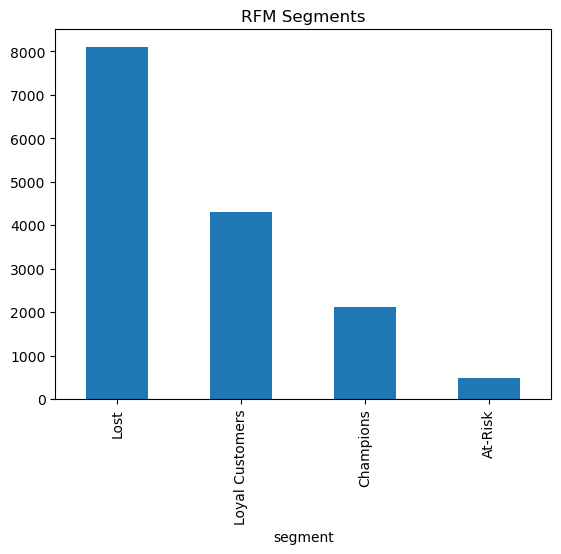

In [8]:
rfm['segment'].value_counts().plot(kind='bar')
plt.title("RFM Segments")
plt.show()

In [9]:
rfm[rfm['segment'] == 'Champions'].head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,segment
16,CUST000017,20,10,3674.08,4,4,4,Champions
19,CUST000020,5,8,3762.15,4,3,4,Champions
26,CUST000027,21,10,2350.36,4,4,3,Champions
28,CUST000029,7,8,2885.93,4,3,4,Champions
29,CUST000030,27,7,3137.62,4,3,4,Champions


In [10]:
rfm[rfm['customer_id'] == 'CUST010401']

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,segment
10389,CUST010401,76,13,4487.87,2,4,4,Loyal Customers


## this is Loyal customer 

In [11]:
rfm.groupby('segment')[['recency','frequency','monetary']].mean()

,recency,frequency,monetary
segment,,,
At-Risk,155.711382,7.325203,1924.712500
Champions,15.384433,9.276222,3199.316070
Lost,133.047931,4.828166,1586.945894
Loyal Customers,106.289143,8.880941,3078.953525


## RFM SEGMENT INSIGHTS



 ## 💡 Insight 1 — Revenue Concentration
A small group (Champions) contributes a disproportionately high share of revenue
These users order frequently and recently

👉 Business Action:

Loyalty rewards
Premium offers
 ## 💡 Insight 2 — Hidden Risk
At-Risk customers previously had high frequency/spend but stopped ordering recently

👉 This is most critical segment

👉 Business Action:

Win-back campaigns
Personalized discounts
## 💡 Insight 3 — Churn Problem
Large portion of customers fall into Lost segment

👉 Indicates:

Weak retention
Poor long-term engagement

## 2-🔁 COHORT ANALYSIS

In [12]:
df['cohort_month'] = df.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
df['order_month'] = df['order_date'].dt.to_period('M')

In [13]:
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

In [14]:
cohort = df.groupby(['cohort_month','cohort_index'])['customer_id'].nunique().reset_index()

cohort_pivot = cohort.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

In [16]:
cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,3719.0,818.0,901.0,882.0,917.0,863.0,942.0,883.0,923.0,907.0,...,910.0,870.0,940.0,891.0,939.0,869.0,875.0,908.0,877.0,913.0
2023-02,2565.0,647.0,636.0,645.0,598.0,632.0,634.0,620.0,633.0,633.0,...,628.0,621.0,613.0,644.0,627.0,615.0,653.0,616.0,652.0,NaN
2023-03,2079.0,516.0,501.0,502.0,506.0,493.0,515.0,495.0,545.0,508.0,...,532.0,493.0,488.0,484.0,473.0,485.0,497.0,532.0,NaN,NaN
2023-04,1558.0,406.0,351.0,354.0,365.0,367.0,389.0,351.0,413.0,369.0,...,352.0,380.0,389.0,377.0,375.0,374.0,397.0,NaN,NaN,NaN
2023-05,1256.0,298.0,298.0,303.0,297.0,302.0,306.0,308.0,312.0,284.0,...,319.0,330.0,290.0,310.0,268.0,337.0,NaN,NaN,NaN,NaN
2023-06,938.0,232.0,224.0,236.0,228.0,223.0,220.0,235.0,220.0,231.0,...,222.0,229.0,225.0,231.0,247.0,NaN,NaN,NaN,NaN,NaN
2023-07,673.0,177.0,144.0,154.0,154.0,151.0,157.0,162.0,170.0,147.0,...,186.0,169.0,162.0,176.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,558.0,127.0,159.0,139.0,141.0,154.0,114.0,137.0,119.0,148.0,...,142.0,141.0,132.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,405.0,87.0,103.0,112.0,103.0,96.0,104.0,96.0,104.0,109.0,...,95.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

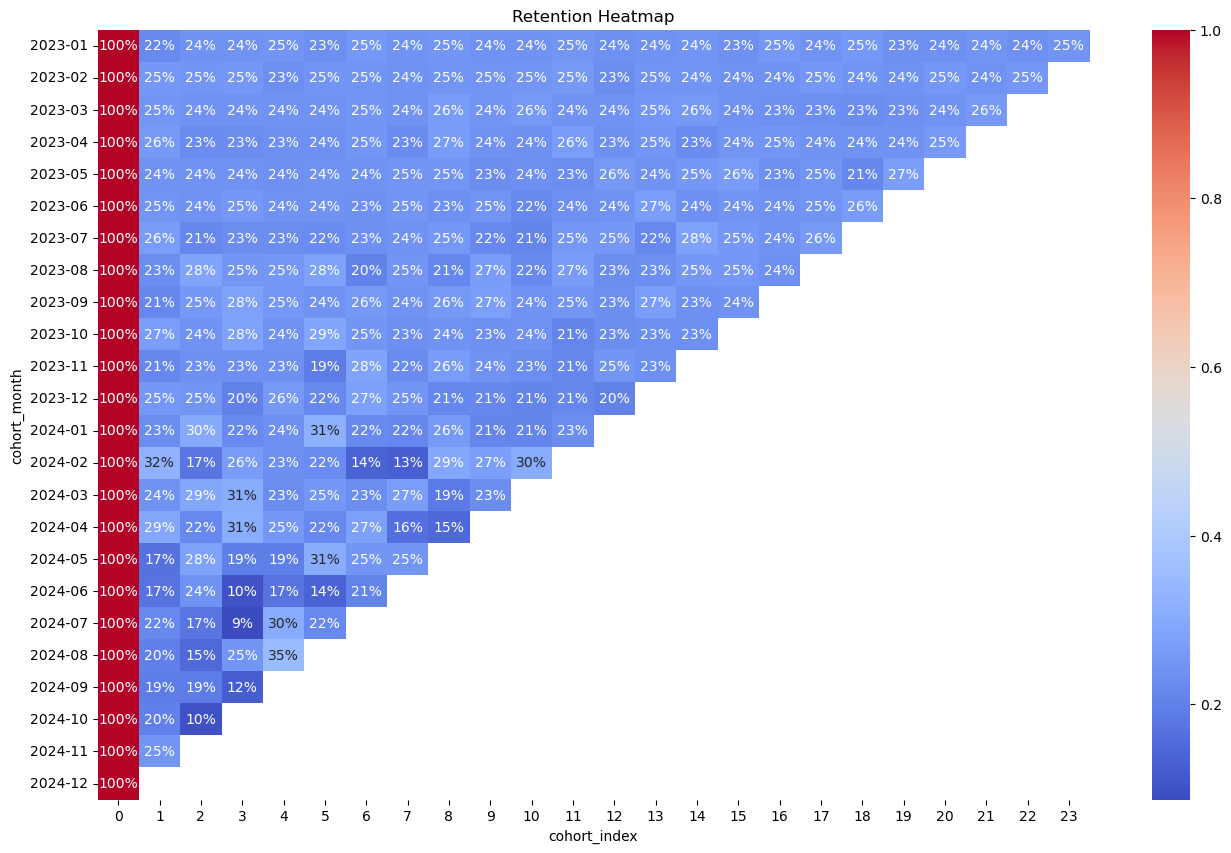

In [19]:
plt.figure(figsize=(16,10))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='coolwarm')
plt.title("Retention Heatmap")
plt.show()

## 💰 3. CLTV

In [20]:
cltv = df.groupby('customer_id').agg({
    'order_value':'mean',
    'order_id':'count',
    'customer_lifetime_days':'max'
}).reset_index()

cltv.columns = ['customer_id','AOV','frequency','lifetime_days']

In [21]:
cltv['lifetime_months'] = cltv['lifetime_days'] / 30

In [22]:
cltv['CLTV'] = cltv['AOV'] * cltv['frequency'] * cltv['lifetime_months']

In [23]:
cltv['CLTV_segment'] = pd.qcut(cltv['CLTV'], 3, labels=['Low','Mid','High'])

In [24]:
cltv

,customer_id,AOV,frequency,lifetime_days,lifetime_months,CLTV,CLTV_segment
0,CUST000001,325.554000,5,324,10.800000,17579.916000,Low
1,CUST000002,290.874000,5,713,23.766667,34565.527000,Mid
2,CUST000003,479.020000,4,246,8.200000,15711.856000,Low
3,CUST000004,386.900000,6,456,15.200000,35285.280000,Mid
4,CUST000005,348.645000,8,323,10.766667,30029.956000,Mid
...,...,...,...,...,...,...,...
14981,CUST014996,262.452222,9,574,19.133333,45194.272667,Mid
14982,CUST014997,310.720000,4,426,14.200000,17648.896000,Low
14983,CUST014998,256.930000,10,550,18.333333,47103.833333,Mid
14984,CUST014999,279.600000,12,652,21.733333,72919.680000,High


## 💡 Insights

👉 High CLTV users = focus group
👉 Revenue concentration

## 📈 4. RETENTION RATE

In [26]:
retention_rate = (df.groupby('customer_id')['order_id'].count() > 1).mean()*100
print(retention_rate)

99.08581342586415


## 💰 5. AOV ANALYSIS

In [27]:
aov = df['order_value'].mean()
print(aov)

df.groupby('city')['order_value'].mean()

336.3140313901345


city
Bengaluru    319.498190
Chennai      337.484027
Delhi        342.841238
Hyderabad    334.686216
Kolkata      357.816135
Mumbai       344.295890
Pune         332.764519
Name: order_value, dtype: float64

 ## 🔥 6. FUNNEL ANALYSIS

In [29]:
total_orders = df.shape[0]
delivered = df[df['order_status']=='Delivered'].shape[0]
rated = df[df['rating'] > 0].shape[0]

print(total_orders, delivered, rated)

100350 82560 70028


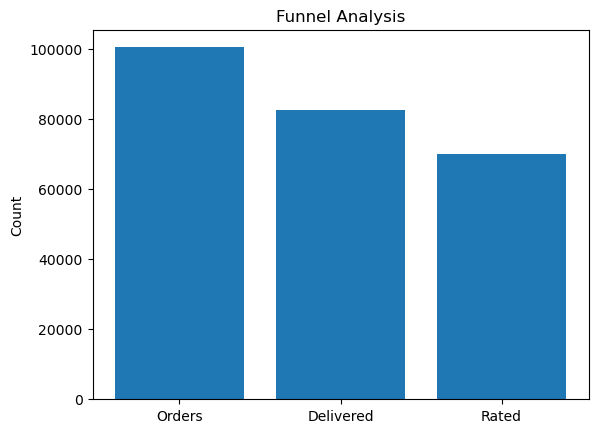

In [31]:
steps = ['Orders','Delivered','Rated']
values = [total_orders, delivered, rated]

plt.bar(steps, values)
plt.title("Funnel Analysis")
plt.ylabel("Count")
plt.show()

## 📊 🧮  FUNNEL DATA
Total Orders = 100,350
Delivered Orders = 82,560
Rated Orders = 70,028

In [33]:
delivery_rate = 82560 / 100350 * 100
rating_rate = 70028 / 82560 * 100

delivery_rate, rating_rate

(82.27204783258595, 84.82073643410853)

 ## 1. DELIVERY PERFORMANCE

👉

~82% orders delivered
~18% orders failed ❌
💡 Insight:

👉 This is significant drop

🎯 Business Meaning:
Operational issue
Cancellation / delay / logistics problem
 ## 🔥 2. CUSTOMER ENGAGEMENT

👉

~85% delivered orders are rated
💡 Insight:

👉 This is actually very good engagement ✅

🟥 🚨 CRITICAL INSIGHT

👉 Biggest problem is:

👉 Order → Delivery drop (18%)

NOT rating

## 🧠 FINAL BUSINESS INSIGHTS
“Nearly 18% of orders fail before delivery, indicating inefficiencies in logistics or order fulfillment.”

“Over 80% of delivered orders receive ratings, suggesting high customer engagement post-delivery.”

“The biggest opportunity lies in improving delivery success rather than post-delivery engagement.”